# Feature Engineering

## Objective

Prepare the cleaned dataset for machine learning using encoding, scaling, and train-test splitting.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

## 1. Load Dataset

In [3]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview

In [4]:
df.shape

(7032, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

### Observation
- 7,032 customer records.
- 21 features.
- Dataset is ready for feature engineering.

## 3. Drop Identifier

In [6]:
df.drop("customerID", axis=1, inplace=True)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7032, 20)

### Observation
- customerID removed.
- Remaining features are suitable for modeling.

## 4. Split Features and Target

In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [10]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [11]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

### Observation
- Features and target variable separated.

## 5. Encode Target Variable

In [12]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [13]:
y[:10]

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

### Observation
- Churn encoded:
  - No = 0
  - Yes = 1

In [14]:
X.shape

(7032, 19)

### Observation

- Features (X) and target (y) separated successfully.
- Churn encoded as:
  - No = 0
  - Yes = 1
- Dataset is ready for feature encoding.

## 6. One-Hot Encoding

### Objective

Convert categorical features into numerical features for machine learning.

In [15]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [16]:
X.shape

(7032, 30)

In [17]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [18]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService

### Observation

- All categorical features converted to numeric.
- Number of features increased after encoding.
- Dataset is ready for scaling.

## 6. One-Hot Encoding

### Objective

Convert categorical features into numerical features for machine learning.

In [20]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [23]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [24]:
X.shape

(7032, 30)

### Observation

- Feature count increased after encoding.

In [25]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


### Observation

- Categorical columns converted into binary (0/1) columns.

In [26]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService

### Observation

- All features are numeric.
- Dataset is ready for feature scaling.

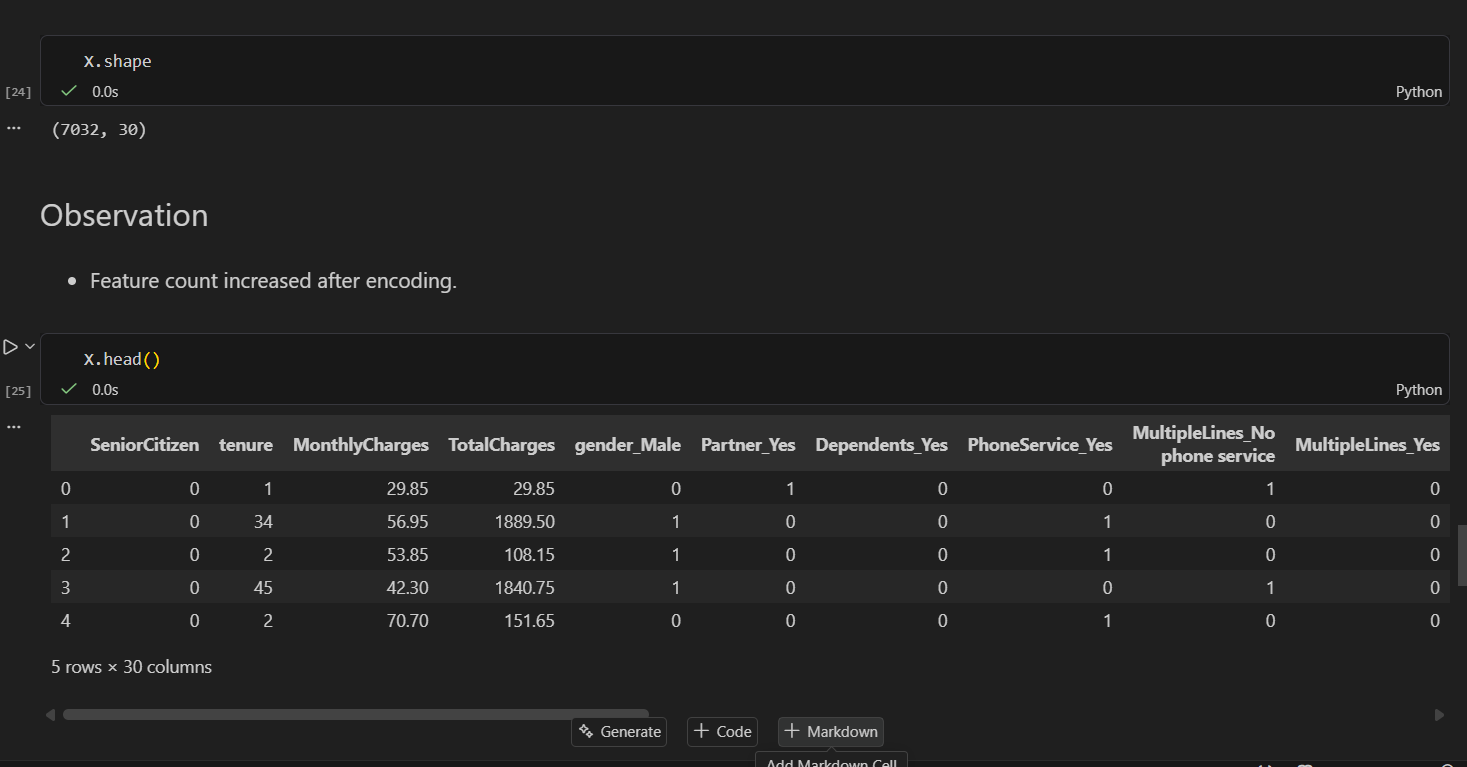

## 7. Feature Scaling

### Objective

Standardize numerical features to improve machine learning model performance.

## 8. Train-Test Split

### Objective

Split the dataset into training and testing sets before scaling.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
X_train.shape

(5625, 30)

In [30]:
X_test.shape

(1407, 30)

In [31]:
y_train.shape

(5625,)

In [32]:
y_test.shape

(1407,)

### Observation

- Dataset split into 80% training and 20% testing.
- Training data will be used to fit the model.
- Testing data will evaluate model performance.

## 9. Feature Scaling

### Objective

Scale numerical features to improve model performance.

In [34]:
scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)

In [36]:

X_test = scaler.transform(X_test)

In [37]:
X_train[:5]

array([[-0.43758982,  0.43467403, -0.51862031, -0.08790784, -1.01378388,
        -0.9624811 , -0.65368396, -3.04070742,  3.04070742, -0.84554067,
        -0.88544634, -0.52984687, -0.52984687, -0.63517172, -0.52984687,
        -0.7281455 , -0.52984687,  1.38474948, -0.52984687, -0.63875661,
        -0.52984687,  1.26181056, -0.52984687,  1.2472596 , -0.51827235,
        -0.5611299 ,  0.83139683, -0.52764485, -0.71475753, -0.54742719],
       [-0.43758982, -1.19565249, -0.3744434 , -0.92128463,  0.98640353,
        -0.9624811 , -0.65368396,  0.32887084, -0.32887084, -0.84554067,
        -0.88544634, -0.52984687, -0.52984687, -0.63517172, -0.52984687,
        -0.7281455 , -0.52984687, -0.72215228, -0.52984687, -0.63875661,
        -0.52984687,  1.26181056, -0.52984687, -0.80175771, -0.51827235,
        -0.5611299 , -1.20279506,  1.89521417, -0.71475753, -0.54742719],
       [-0.43758982,  0.92377199,  0.43261589,  0.96378055, -1.01378388,
         1.03898144, -0.65368396,  0.32887084, -0

In [38]:
X_train.shape

(5625, 30)

In [39]:

X_test.shape

(1407, 30)

### Observation

- Numerical features standardized.
- Training and testing data scaled separately.
- Dataset ready for model building.

## 10. Save Processed Data

### Objective

Save processed datasets for model training.

In [40]:
X_train = pd.DataFrame(X_train, columns=X.columns)

X_test = pd.DataFrame(X_test, columns=X.columns)

In [41]:
X_train.to_csv("../data/processed/X_train.csv", index=False)

X_test.to_csv("../data/processed/X_test.csv", index=False)

pd.DataFrame(y_train).to_csv("../data/processed/y_train.csv", index=False)

pd.DataFrame(y_test).to_csv("../data/processed/y_test.csv", index=False)

In [42]:
import os

os.listdir("../data/processed")

['customer_churn_cleaned.csv',
 'customer_churn_cleaned_1.csv',
 'X_test.csv',
 'X_train.csv',
 'y_test.csv',
 'y_train.csv']

### Observation

- Processed datasets saved successfully.
- Data is ready for machine learning models.

## 11. Save Scaler

### Objective

Save the trained scaler for future predictions.

In [43]:
import joblib

In [44]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [45]:
import os

os.listdir("../models")

['scaler.pkl']

### Observation

- StandardScaler saved successfully.
- Same scaler will be used during prediction.